# LIBRAIRIES

In [1]:
import numpy as np
import json, random, torch

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

# HuggingFace transformers
from transformers import GPT2LMHeadModel, GPT2Tokenizer

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#MAX_NEW_TOKEN_LENGTH = 50
MAX_LENGHT_TOKENIZER = 50 # <= 1024 limite GPT-2
BATCH_SIZE = 4

# DATA

In [4]:
folder_path = "/content/drive/MyDrive/genai/"

# Load datasets from your genai folder
with open(f"{folder_path}eval_subset.json", "r") as f:
    eval_subset = json.load(f)

with open(f"{folder_path}train_subset.json", "r") as f:
    train_subset = json.load(f)

print(f"Eval examples: {len(eval_subset)}")
print(f"Train examples: {len(train_subset)}")

Eval examples: 500
Train examples: 5000


In [5]:
train_subset[0]

{'table_id': 'List of 8/9 PM telenovelas of Rede Globo',
 'serialized_table': 'Title : A Favorita',
 'reference': 'A Favorita is the telenovela aired in the 9 pm timeslot.'}

# MODEL

## **Device**

In [6]:
# Move model to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


## **Model loading**

In [7]:
# Load GPT-2 small model and tokenizer
model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

# Set padding token (important for generation)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

model.to(device)

print(f"Model loaded on {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded on cuda


## **Generation Function**

In [8]:
def generate_batch(model, tokenizer, input_ids, attention_mask, max_new_tokens):

    """
    Generate text using GPT-2 given a prompt
    """

    outputs = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

    decoded_outputs = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    decoded_prompts = tokenizer.batch_decode(input_ids, skip_special_tokens=True)

    cleaned = []
    for p, full in zip(decoded_prompts, decoded_outputs):
        if full.startswith(p):
            cleaned.append(full[len(p):].strip())
        else:
            cleaned.append(full.strip())

    return cleaned

# DATASET

## **Dataset class**

In [9]:
class TableDataset(Dataset):

    def __init__(self, folder_path,split, tokenizer, max_length, few_shot):

        self.root_folder = f"{folder_path}{split}_subset.json"
        with open(self.root_folder, "r") as f:
            self.data = json.load(f)
        self.split = split
        self.few_shot = few_shot
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.samples = []

        counter = 0
        for item in self.data:
            table = item["serialized_table"]
            label = item["reference"]
            self.samples.append(
                {"id" : counter,
                 "table" : table,
                 "label" : label})
            counter += 1

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        sample = self.samples[idx]

        if not self.few_shot: # Zero-shot generation

            prompt = self.build_prompt(sample["table"])

        else:                 # Few-shot generation

            few_examples = random.sample(self.data, k=3)
            prompt = self.build_prompt(sample["table"], examples=few_examples)

        # --- INPUT
        inputs = self.tokenizer(
            prompt,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )

        # --- TARGET
        target = self.tokenizer(
            sample["label"],
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )

        return {
            "table": sample["table"],
            "prompt": prompt,
            "labels_str": sample["label"],
            "input_ids": inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "labels": target["input_ids"].squeeze(0)
        }


    # Prompt builder
    def build_prompt(self, serialized_table, examples=None):
        """
        Build a prompt for GPT-2.

        If examples are provided → few-shot
        Otherwise → zero-shot
        """

        prompt = ""

        # few-shot examples
        if examples:
            for ex in examples:
                prompt += f"Table: {ex['serialized_table']}\n"
                prompt += f"Description: {ex['reference']}\n\n"

        # target table
        prompt += f"Table: {serialized_table}\n"
        prompt += "Description:"

        return prompt


In [10]:
train_dataset_zeroshot = TableDataset(
    folder_path, "train", tokenizer,
    MAX_LENGHT_TOKENIZER, few_shot=False)

eval_dataset_zeroshot = TableDataset(
    folder_path, "eval", tokenizer,
    MAX_LENGHT_TOKENIZER, few_shot=False)

In [11]:
train_dataset_zeroshot[1]

{'table': 'Year : 2018 | Player name : Roquan Smith | Position : Linebacker | College : Georgia',
 'prompt': 'Table: Year : 2018 | Player name : Roquan Smith | Position : Linebacker | College : Georgia\nDescription:',
 'labels_str': 'The Chicago Bears recent first round selection (2018) was Roquan Smith, an inside linebacker from Georgia.',
 'input_ids': tensor([50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 10962,    25,  6280,  1058,  2864,
           930,  7853,  1438,  1058,  5564,   421,   272,  4176,   930, 23158,
          1058,  6910, 49978,   930,  5535,  1058,  7859,   198, 11828,    25]),
 'attention_mask': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1]),
 'labels': tensor([50256, 50256, 50256, 50256, 502

# METRICS

## **BERT-Score**

In [12]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased").to(device).eval()


def get_embeddings_batch(texts):
    inputs = bert_tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = bert_model(**inputs)

    return outputs.last_hidden_state  # (B, seq_len, hidden)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
def bertscore_batch(preds, refs):

    emb_pred = get_embeddings_batch(preds)
    emb_ref = get_embeddings_batch(refs)

    scores = []

    for i in range(len(preds)):

        p = emb_pred[i]  # (len_p, dim)
        r = emb_ref[i]   # (len_r, dim)

        # normalisation
        p = F.normalize(p, dim=1)
        r = F.normalize(r, dim=1)

        sim = torch.mm(p, r.T)

        precision = sim.max(dim=1).values.mean()
        recall = sim.max(dim=0).values.mean()

        f1 = 2 * precision * recall / (precision + recall + 1e-8)

        scores.append(f1.item())

    return sum(scores) / len(scores)

In [14]:
def evaluate_bertscore(loader, model, tokenizer, device, max_new_tokens, log_inter=10):

    model.eval()
    all_scores = []

    with torch.no_grad():

        for idx_bt, batch in enumerate(loader):

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            refs = batch["labels_str"]

            preds = generate_batch(
                model,
                tokenizer,
                input_ids,
                attention_mask,
                max_new_tokens
            )

            score = bertscore_batch(preds, refs)
            all_scores.append(score)

            if len(all_scores) % log_inter == 0:
                print(f"Batch {idx_bt+1}/{len(loader)} "
                      f"\t-> BERTScore: {sum(all_scores)/len(all_scores):.4f}")

    return sum(all_scores) / len(all_scores)


## **BLEU / ROUGE**

In [15]:
# TODO

## **Self-BLEU**

In [16]:
# TODO

## **Manual faithfulness**

In [17]:
# TODO
# Idée : créer un dataframe avec : table, ref/label, pred_zero-shot, pred_few-shot pour 50 exemples de test

# ZERO-SHOT

## **Config**



How to fix MAX_NEW_TOKEN_LENGTH & MAX_LENGHT_TOKENIZER ?

-> Use the 95e percentile

In [18]:
train_dataset_zeroshot = TableDataset(
    folder_path, "train", tokenizer,
    1024, few_shot=False)

In [19]:
PAD_TOKEN = tokenizer.eos_token_id
nb_token_in_label = []
nb_token_in_prompt = []
for el in train_dataset_zeroshot:
    nb_token_in_label.append(torch.sum(el['labels'] != PAD_TOKEN).item())
    nb_token_in_prompt.append(torch.sum(el['input_ids'] != PAD_TOKEN).item())


In [20]:

p_prompt = np.percentile(nb_token_in_prompt, 95)
p_label = np.percentile(nb_token_in_label, 95)

print('Percentile 0.95:')
print(f'Prompt: {p_prompt} \t <--- MAX_LENGTH_TOKENIZER')
print(f'Label: {p_label} \t <--- MAX_NEW_TOKEN')

MAX_LENGHT_TOKENIZER_ZS = int(p_prompt)
MAX_NEW_TOKEN_LENGTH = int(p_label)

print()
print(f"MAX_LENGHT_TOKENIZER_ZS: {MAX_LENGHT_TOKENIZER_ZS}")
print(f"MAX_NEW_TOKEN_LENGTH: {MAX_NEW_TOKEN_LENGTH}")

Percentile 0.95:
Prompt: 64.0 	 <--- MAX_LENGTH_TOKENIZER
Label: 40.0 	 <--- MAX_NEW_TOKEN

MAX_LENGHT_TOKENIZER_ZS: 64
MAX_NEW_TOKEN_LENGTH: 40


## **Data**

In [21]:
# train_dataset_zeroshot = TableDataset(
#     folder_path, "train", tokenizer,
#     MAX_LENGHT_TOKENIZER_ZS, few_shot=True)

eval_dataset_zeroshot = TableDataset(
    folder_path, "eval", tokenizer,
    MAX_LENGHT_TOKENIZER_ZS, few_shot=True)

In [22]:
# train_dataloader_zeroshot = torch.utils.data.DataLoader(
#     train_dataset_zeroshot, batch_size=BATCH_SIZE, shuffle=True)

eval_dataloader_zeroshot = torch.utils.data.DataLoader(
    eval_dataset_zeroshot, batch_size=BATCH_SIZE, shuffle=False)


## **Eval**

### **BERTScore**

In [23]:
bert_score_zs = evaluate_bertscore(
    eval_dataloader_zeroshot,
    model,
    tokenizer,
    device,
    max_new_tokens=MAX_NEW_TOKEN_LENGTH,
    log_inter=10
)

print(f"\n[EVAL] BERTScore: {bert_score_zs:.4f}")

Batch 10/125 	-> BERTScore: 0.3827
Batch 20/125 	-> BERTScore: 0.3848
Batch 30/125 	-> BERTScore: 0.3895
Batch 40/125 	-> BERTScore: 0.3948
Batch 50/125 	-> BERTScore: 0.3937
Batch 60/125 	-> BERTScore: 0.3942
Batch 70/125 	-> BERTScore: 0.3947
Batch 80/125 	-> BERTScore: 0.3961
Batch 90/125 	-> BERTScore: 0.3941
Batch 100/125 	-> BERTScore: 0.3933
Batch 110/125 	-> BERTScore: 0.3924
Batch 120/125 	-> BERTScore: 0.3928

[EVAL] BERTScore: 0.3934


### **BLEU / ROUGE**

In [24]:
# TODO

In [25]:
bleu_score_zs = 0
rouge_score_zs = 0

### **Self-BLEU**

In [26]:
# TODO

In [27]:
self_bleu_score_zs = 0

# FEW-SHOT

## **Config**

In [28]:
train_dataset_fewshot = TableDataset(
    folder_path, "train", tokenizer,
    1024, few_shot=True)

In [29]:
PAD_TOKEN = tokenizer.eos_token_id
nb_token_in_label = []
nb_token_in_prompt = []
for el in train_dataset_fewshot:
    nb_token_in_prompt.append(torch.sum(el['input_ids'] != PAD_TOKEN).item())


In [30]:
p_prompt = np.percentile(nb_token_in_prompt, 95)

print('Percentile 0.95:')
print(f'Prompt: {p_prompt} \t <--- MAX_LENGTH_TOKENIZER')

MAX_LENGHT_TOKENIZER_FS = int(p_prompt)

print()
print(f"MAX_LENGHT_TOKENIZER_FS: {MAX_LENGHT_TOKENIZER_FS}")
print(f"MAX_NEW_TOKEN_LENGTH: {MAX_NEW_TOKEN_LENGTH}")

Percentile 0.95:
Prompt: 293.0 	 <--- MAX_LENGTH_TOKENIZER

MAX_LENGHT_TOKENIZER_FS: 293
MAX_NEW_TOKEN_LENGTH: 40


## **Data**

In [31]:
# train_dataset_fewshot = TableDataset(
#     folder_path, "train", tokenizer,
#     MAX_LENGHT_TOKENIZER_FS, few_shot=True)

eval_dataset_fewshot = TableDataset(
    folder_path, "eval", tokenizer,
    MAX_LENGHT_TOKENIZER_FS, few_shot=True)

In [32]:
# train_dataloader_fewshot = torch.utils.data.DataLoader(
#     train_dataset_fewshot, batch_size=BATCH_SIZE, shuffle=True)

eval_dataloader_fewshot = torch.utils.data.DataLoader(
    eval_dataset_fewshot, batch_size=BATCH_SIZE, shuffle=False)


## **Eval**

### **BERTScore**

In [33]:
bert_score_fs = evaluate_bertscore(
    eval_dataloader_fewshot,
    model,
    tokenizer,
    device,
    max_new_tokens=MAX_NEW_TOKEN_LENGTH,
    log_inter=10
)

print(f"\n[EVAL] BERTScore: {bert_score_fs:.4f}")

Batch 10/125 	-> BERTScore: 0.5105
Batch 20/125 	-> BERTScore: 0.5169
Batch 30/125 	-> BERTScore: 0.5231
Batch 40/125 	-> BERTScore: 0.5228
Batch 50/125 	-> BERTScore: 0.5213
Batch 60/125 	-> BERTScore: 0.5211
Batch 70/125 	-> BERTScore: 0.5231
Batch 80/125 	-> BERTScore: 0.5248
Batch 90/125 	-> BERTScore: 0.5235
Batch 100/125 	-> BERTScore: 0.5258
Batch 110/125 	-> BERTScore: 0.5280
Batch 120/125 	-> BERTScore: 0.5302

[EVAL] BERTScore: 0.5306


### **BLEU / ROUGE**

In [34]:
# TODO

In [35]:
bleu_score_fs = 0
rouge_score_fs = 0

### **Self-BLEU**

In [36]:
# TODO

In [37]:
self_bleu_score_fs = 0

# COMPARISON

## **Quantitative**

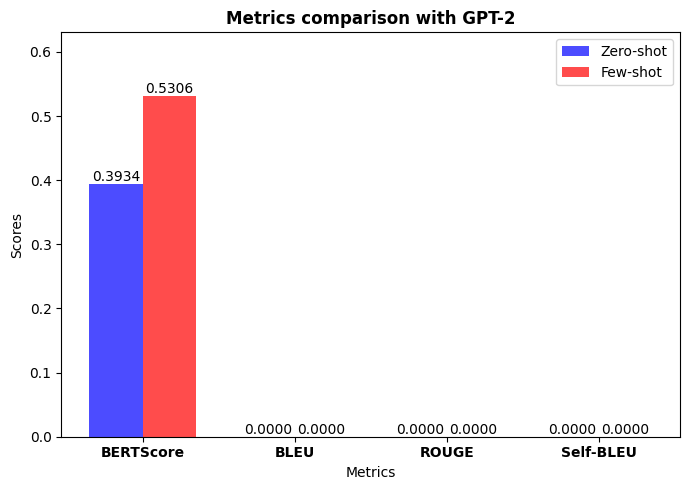

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# métriques
metrics = ["BERTScore", "BLEU", "ROUGE", "Self-BLEU"]

# valeurs (exemple → remplace par les tiennes)
zeroshot_scores = [bert_score_zs, bleu_score_zs, rouge_score_zs, self_bleu_score_zs]
fewshot_scores  = [bert_score_fs, bleu_score_fs, rouge_score_fs, self_bleu_score_fs]

# positions des barres
x = np.arange(len(metrics))
width = 0.35

# plot
plt.figure(figsize=(7,5))

plt.bar(x - width/2, zeroshot_scores, width, label="Zero-shot", color="b", alpha=0.7)
plt.bar(x + width/2, fewshot_scores,  width, label="Few-shot", color='r', alpha=0.7)

for bar in plt.gca().containers:
    plt.bar_label(bar, label_type='edge', fmt='%.4f')

# labels
plt.xlabel("Metrics")
plt.ylabel("Scores")
plt.title("Metrics comparison with GPT-2", fontweight='bold')
plt.xticks(x, metrics, fontweight='bold')
plt.ylim(0, max(max(zeroshot_scores), max(fewshot_scores)) + 0.1)
plt.legend()

plt.tight_layout()
plt.show()

## **Qualitative**

-> Manual faithfulness

In [39]:
# TODO
# print le dataframe avec : table, ref/label, pred_zs, pred_fs pour 50 exemples de test

#